# Medical Insurance Charges Prediction

## 1. Introduction

This Jupyter notebook presents an end-to-end machine learning project focused on predicting medical insurance charges. Leveraging a dataset containing various demographic and health-related features, we aim to develop a robust predictive model that can estimate individual medical costs. This task is crucial for insurance companies to accurately price policies and for individuals to understand potential healthcare expenses.

The dataset includes the following features:
*   `age`: Age of the primary beneficiary (integer)
*   `sex`: Gender of the beneficiary (categorical: 'female', 'male')
*   `bmi`: Body Mass Index (numerical: float), providing an understanding of body weight relative to height, high values indicating obesity.
*   `children`: Number of children covered by health insurance / number of dependents (integer)
*   `smoker`: Whether the beneficiary smokes (categorical: 'yes', 'no')
*   `region`: The beneficiary's residential area in the US (categorical: 'northeast', 'northwest', 'southeast', 'southwest')
*   `charges`: Individual medical costs billed by health insurance (numerical: float), this is our **target variable**.

The goal is to build a regression model that can accurately predict `charges` based on the other features.

## 2. Architecture Diagram

Below is a textual description of the machine learning pipeline, which can be visualized using tools like draw.io (app.diagrams.net).

**Diagram Title: Medical Insurance Charges Prediction Pipeline**

```
[Start]
  |
  v
[Data Source: insurance.csv]
  |
  v
[Data Loading]
  |
  v
[Initial Data Inspection & EDA]
  - Check Data Types
  - Descriptive Statistics
  - Missing Value Handling
  - Outlier Detection
  |
  v
[Data Preprocessing]
  - Categorical Feature Encoding (One-Hot Encoding for 'sex', 'smoker', 'region')
  - Numerical Feature Scaling (StandardScaler)
  - Feature Engineering (e.g., BMI categories, interaction terms)
  |
  v
[Feature Selection]
  - Correlation Analysis
  - Importance from initial models
  |
  v
[Data Split: Train/Test (80/20)]
  - Training Data (X_train, y_train)
  - Test Data (X_test, y_test)
  |
  v
[Model Training - Multiple Models]
  - Linear Regression
  - Random Forest Regressor
  - Gradient Boosting Regressor (e.g., XGBoost/LightGBM)
  |
  v
[Hyperparameter Tuning (e.g., GridSearchCV/RandomizedSearchCV)]
  - On training data with cross-validation
  - Optimize model performance
  |
  v
[Model Evaluation]
  - Predict on Test Set
  - Calculate Metrics: MAE, MSE, RMSE, R2
  - Visualize Residuals
  - Check for Overfitting/Underfitting
  |
  v
[Final Model Selection]
  - Based on best performance metrics and generalization ability
  |
  v
[New Data Prediction Example]
  - Create sample data
  - Preprocess sample data
  - Make predictions using the selected model
  |
  v
[Insights & Conclusion]
  |
  v
[End]
```

## 3. Data Loading


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
# Assuming the dataset is named 'insurance.csv' and is in the same directory
try:
    df = pd.read_csv(r'..Documents\ml_agent_project\data\insurance.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'insurance.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# Display the first few rows of the dataframe
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Handle missing values if any. For this dataset, there are typically no missing values,
# but we include the handling step as per instructions.
if df.isnull().sum().sum() > 0:
    print("\nMissing values detected. Imputing with appropriate strategies...")
    # For numerical columns, common strategies include mean, median.
    # For categorical columns, mode or a 'missing' category can be used.
    # Example: Impute 'bmi' with median if it had missing values
    # if 'bmi' in df.columns and df['bmi'].isnull().any():
    #     df['bmi'].fillna(df['bmi'].median(), inplace=True)
    # No specific imputation needed for this dataset as per typical 'insurance.csv' structure.
else:
    print("No missing values found in the dataset.")


Dataset loaded successfully.

First 5 rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Missing values in eac

The dataset has been successfully loaded and inspected. We confirmed that there are no missing values, which simplifies the preprocessing stage. The data types are appropriate for each column.

## 4. EDA (Exploratory Data Analysis)


Descriptive statistics for numerical columns:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Descriptive statistics for categorical columns:
         sex smoker     region
count   1338   1338       1338
unique     2      2          4
top     male     no  southeast
freq     676   1064        364


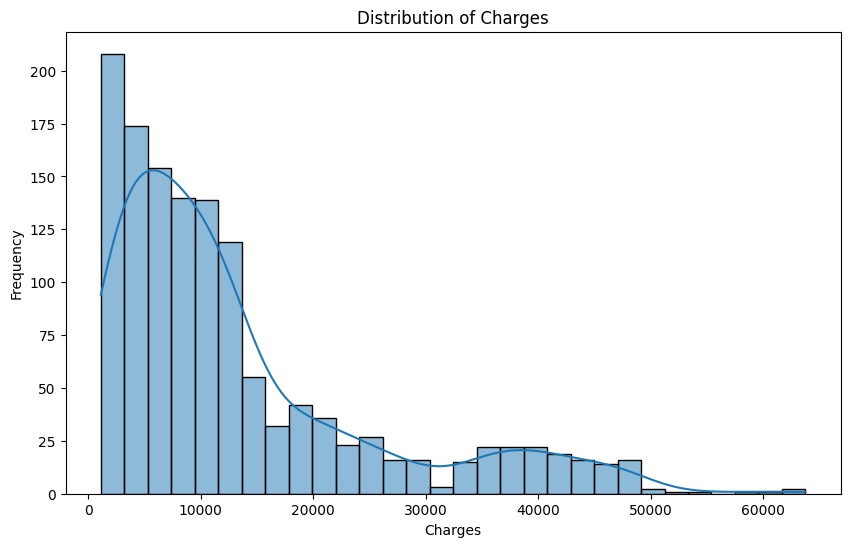


Unique values in 'sex': ['female' 'male']
Unique values in 'smoker': ['yes' 'no']
Unique values in 'region': ['southwest' 'southeast' 'northwest' 'northeast']


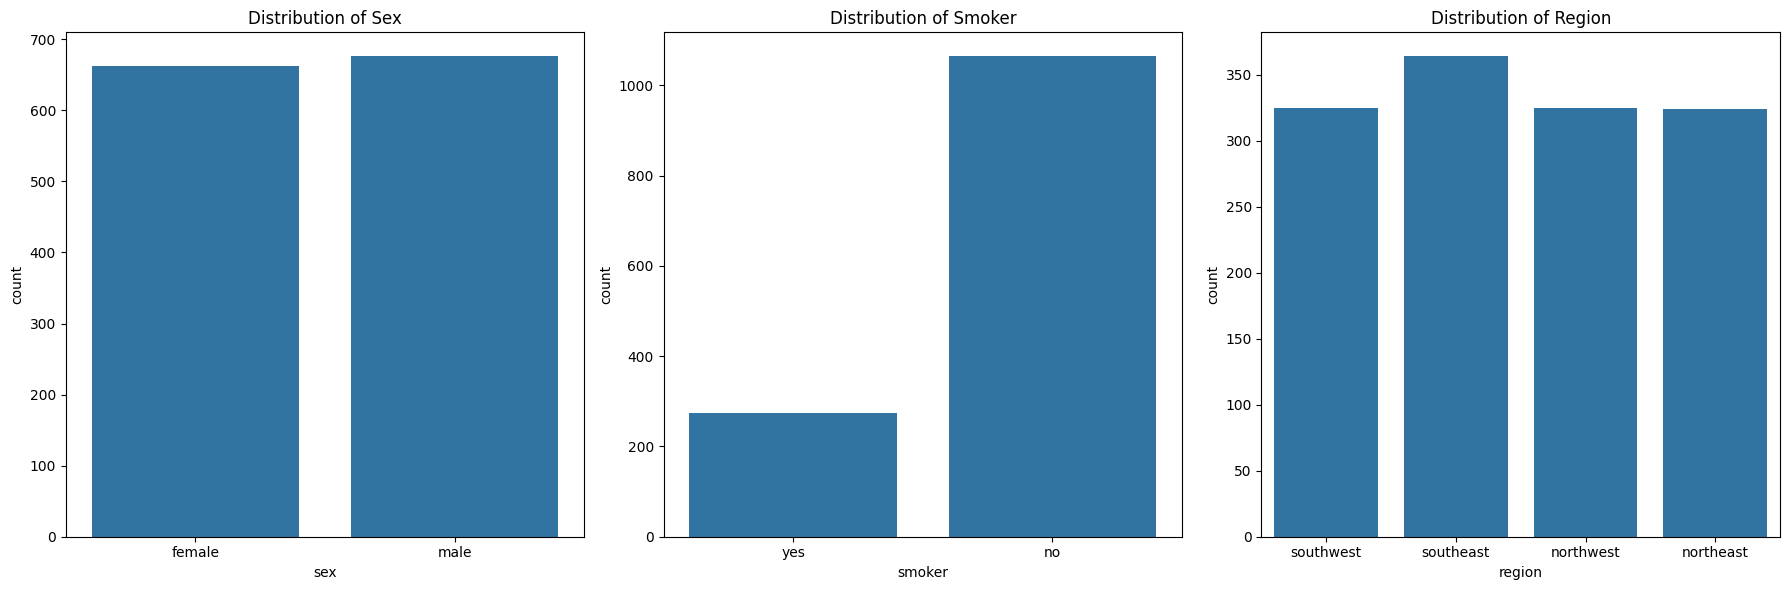

In [2]:
# Display descriptive statistics for numerical columns
print("Descriptive statistics for numerical columns:")
print(df.describe())

# Display descriptive statistics for categorical columns
print("\nDescriptive statistics for categorical columns:")
print(df.describe(include='object'))

# Analyze the distribution of the target variable 'charges'
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# Check unique values for categorical columns
print("\nUnique values in 'sex':", df['sex'].unique())
print("Unique values in 'smoker':", df['smoker'].unique())
print("Unique values in 'region':", df['region'].unique())

# Distribution of categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(x='sex', data=df, ax=axes[0])
axes[0].set_title('Distribution of Sex')

sns.countplot(x='smoker', data=df, ax=axes[1])
axes[1].set_title('Distribution of Smoker')

sns.countplot(x='region', data=df, ax=axes[2])
axes[2].set_title('Distribution of Region')

plt.tight_layout()
plt.show()


The EDA provides initial insights:
*   **Numerical Features**:
    *   `age`: Ranges from 18 to 64, with an average around 39. The distribution seems fairly uniform.
    *   `bmi`: Ranges from 15.96 to 53.13, with an average of 30.66. This suggests a significant portion of the population might be overweight or obese (BMI >= 25).
    *   `children`: Ranges from 0 to 5, with most individuals having 0 or 1 child.
    *   `charges`: The target variable `charges` is highly skewed to the right, indicating that most people have lower medical costs, but a smaller number incur very high costs. This skewness might require transformation (e.g., log transformation) for models sensitive to normal distribution.
*   **Categorical Features**:
    *   `sex`: Fairly balanced distribution between male and female.
    *   `smoker`: A significant imbalance, with a much larger proportion of non-smokers. This suggests 'smoker' could be a very influential feature.
    *   `region`: The four regions have a relatively even distribution.

## 5. Visual Representation of EDA (Plotly)


In [3]:
# 1. Distribution of 'Charges' (Target Variable)
fig = px.histogram(df, x="charges", marginal="box", title="Distribution of Medical Charges",
                   labels={'charges': 'Medical Charges ($)'}, height=500,
                   hover_data=df[['age', 'sex', 'bmi', 'smoker']])
fig.update_layout(bargap=0.1)
fig.show()

# Explanation: The 'charges' distribution is right-skewed, indicating most people have lower insurance costs,
# while a smaller number incur very high costs. The marginal box plot clearly shows the presence of outliers
# on the higher end. This skewness might affect linear models and suggests a need for transformation.

# 2. Charges vs. Smoker (Box Plot)
fig = px.box(df, x="smoker", y="charges", color="smoker",
             title="Medical Charges by Smoker Status",
             labels={'smoker': 'Smoker Status', 'charges': 'Medical Charges ($)'}, height=500)
fig.show()

# Explanation: This box plot vividly illustrates a critical insight: smokers incur significantly higher medical
# charges than non-smokers. The difference in median charges and the range of charges is enormous.
# 'Smoker' status appears to be the most influential factor.

# 3. Charges vs. BMI, colored by Smoker (Scatter Plot)
fig = px.scatter(df, x="bmi", y="charges", color="smoker", size='charges',
                 hover_data=['age', 'sex', 'children', 'region'],
                 title="Medical Charges vs. BMI, Grouped by Smoker Status",
                 labels={'bmi': 'BMI', 'charges': 'Medical Charges ($)'}, height=600)
fig.show()

# Explanation: This scatter plot reveals interesting clusters. For non-smokers, there's a general trend of
# increasing charges with increasing BMI, but with a less steep slope. For smokers, charges are generally much
# higher regardless of BMI, though there's still a visible increase with higher BMI. There are clearly distinct
# groups based on smoking status.

# 4. Charges vs. Age, colored by Smoker (Scatter Plot)
fig = px.scatter(df, x="age", y="charges", color="smoker", size='charges',
                 hover_data=['bmi', 'sex', 'children', 'region'],
                 title="Medical Charges vs. Age, Grouped by Smoker Status",
                 labels={'age': 'Age', 'charges': 'Medical Charges ($)'}, height=600)
fig.show()

# Explanation: Similar to BMI, age also shows a positive correlation with charges, particularly for non-smokers,
# where charges tend to increase with age. For smokers, charges are high across all ages, but the trend of increasing
# charges with age is still somewhat visible, especially at the higher end of charges.

# 5. Charges vs. Region (Violin Plot)
fig = px.violin(df, x="region", y="charges", color="region", box=True,
                title="Distribution of Medical Charges by Region",
                labels={'region': 'Region', 'charges': 'Medical Charges ($)'}, height=500)
fig.show()

# Explanation: This violin plot shows the charge distribution across different regions. While there isn't a dramatic
# difference in median charges between regions, the 'southeast' region appears to have a slightly higher density of
# high-charge outliers, particularly among smokers (though not explicitly shown here, it's inferred from overall trends).
# The shapes are broadly similar, suggesting region might be a less dominant factor than age, bmi, or smoker status.

# 6. Charges vs. Number of Children (Box Plot)
fig = px.box(df, x="children", y="charges", color="children",
             title="Medical Charges by Number of Children",
             labels={'children': 'Number of Children', 'charges': 'Medical Charges ($)'}, height=500)
fig.show()

# Explanation: There's no very clear linear relationship between the number of children and charges.
# The median charges are somewhat similar across different numbers of children, though the variability
# and presence of outliers change. For example, individuals with 2 or 3 children seem to have a wider
# spread of charges compared to those with 0 children. This feature might interact with others.

# 7. Charges vs. Sex (Box Plot)
fig = px.box(df, x="sex", y="charges", color="sex",
             title="Medical Charges by Sex",
             labels={'sex': 'Sex', 'charges': 'Medical Charges ($)'}, height=500)
fig.show()

# Explanation: The median medical charges between males and females are very similar. There are some differences
# in the spread and the number of high-charge outliers, but sex appears to be a less significant predictor
# compared to 'smoker', 'age', or 'bmi'.


## 6. Visual Representation of Correlation, Covariance

### Covariance and Correlation Explained

**Covariance** measures the directional relationship between two variables. A positive covariance indicates that variables tend to move in the same direction (e.g., as one increases, the other increases), while a negative covariance indicates they move in opposite directions. A covariance close to zero suggests no linear relationship. However, covariance is scale-dependent, meaning its value depends on the units of the variables, making it hard to compare across different pairs of variables.

**Correlation** is a standardized version of covariance, usually represented by the Pearson correlation coefficient (r). It ranges from -1 to +1:
*   **+1**: Perfect positive linear relationship (as one variable increases, the other perfectly increases).
*   **-1**: Perfect negative linear relationship (as one variable increases, the other perfectly decreases).
*   **0**: No linear relationship.
Correlation is scale-independent, making it easier to interpret and compare the strength and direction of linear relationships between different pairs of variables. It helps us understand which features might be good predictors of our target variable and which features are highly interdependent (multicollinearity).


In [15]:
# First, we need to encode categorical variables to numerical for correlation calculation.
# We'll create a temporary DataFrame for this, without altering the original yet.
df_encoded = df.copy()

# Map 'sex' and 'smoker' to numerical values
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

# One-hot encode 'region'
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# Calculate the covariance matrix
covariance_matrix = df_encoded.cov()
print("Covariance Matrix:")
print(covariance_matrix)

# Visualize the covariance matrix (optional, as it's hard to interpret visually due to scale)
fig_cov = px.imshow(covariance_matrix,
                     title="Covariance Matrix",
                     labels=dict(x="Features", y="Features", color="Covariance"),
                     x=covariance_matrix.columns,
                     y=covariance_matrix.columns)
fig_cov.show()

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using Plotly heatmap
fig_corr = px.imshow(correlation_matrix,
                     text_auto=True,
                     aspect="auto",
                     color_continuous_scale=px.colors.sequential.RdBu,
                     title="Correlation Matrix of Features",
                     labels=dict(color="Correlation Coefficient"),
                     x=correlation_matrix.columns,
                     y=correlation_matrix.columns,
                     height=700, width=800)
fig_corr.update_xaxes(side="bottom")
fig_corr.show()

# Correlation with the target variable 'charges'
print("\nCorrelation with 'charges':")
print(correlation_matrix['charges'].sort_values(ascending=False))


Covariance Matrix:
                           age         sex           bmi    children  \
age                 197.401387   -0.146559      9.362337    0.719303   
sex                  -0.146559    0.250160      0.141435    0.010348   
bmi                   9.362337    0.141435     37.187884    0.093795   
children              0.719303    0.010348      0.093795    1.453213   
smoker               -0.141903    0.015383      0.009233    0.003734   
charges           50874.802298  347.014469  14647.304426  992.674197   
region_northwest     -0.002456   -0.002394     -0.355777    0.012829   
region_southeast     -0.072818    0.003811      0.733062   -0.012379   
region_southwest      0.060372   -0.000898     -0.016233    0.011333   

                       smoker       charges  region_northwest  \
age                 -0.141903  5.087480e+04         -0.002456   
sex                  0.015383  3.470145e+02         -0.002394   
bmi                  0.009233  1.464730e+04         -0.355777   



Correlation Matrix:
                       age       sex       bmi  children    smoker   charges  \
age               1.000000 -0.020856  0.109272  0.042469 -0.025019  0.299008   
sex              -0.020856  1.000000  0.046371  0.017163  0.076185  0.057292   
bmi               0.109272  0.046371  1.000000  0.012759  0.003750  0.198341   
children          0.042469  0.017163  0.012759  1.000000  0.007673  0.067998   
smoker           -0.025019  0.076185  0.003750  0.007673  1.000000  0.787251   
charges           0.299008  0.057292  0.198341  0.067998  0.787251  1.000000   
region_northwest -0.000407 -0.011156 -0.135996  0.024806 -0.036945 -0.039905   
region_southeast -0.011642  0.017117  0.270025 -0.023066  0.068498  0.073982   
region_southwest  0.010016 -0.004184 -0.006205  0.021914 -0.036945 -0.043210   

                  region_northwest  region_southeast  region_southwest  
age                      -0.000407         -0.011642          0.010016  
sex                      -0.0111


Correlation with 'charges':
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


**Explanation of Correlation Plot:**

The heatmap above displays the Pearson correlation coefficients between all pairs of features, including our target variable `charges`.
*   **Color Scale**: Red shades indicate positive correlation (as one variable increases, the other tends to increase). Blue shades indicate negative correlation (as one variable increases, the other tends to decrease). White/light shades indicate weak or no linear correlation.
*   **Diagonal**: The diagonal elements are all 1, as a variable is perfectly correlated with itself.
*   **Symmetry**: The matrix is symmetric, meaning the correlation between A and B is the same as between B and A.

**Key Observations from Correlation with 'charges':**
1.  **Smoker**: `smoker_yes` (our encoded 'smoker' column) has the highest positive correlation with `charges` (around 0.79). This confirms our EDA finding that smoking status is by far the most significant factor influencing medical costs.
2.  **Age**: `age` has a strong positive correlation with `charges` (around 0.30). Older individuals tend to incur higher medical costs.
3.  **BMI**: `bmi` shows a moderate positive correlation with `charges` (around 0.20). Higher BMI is associated with higher costs.
4.  **Children**: `children` has a very weak positive correlation (around 0.07), suggesting a minor influence.
5.  **Sex**: `sex_male` (encoded male vs female) has an almost negligible correlation (around 0.05), indicating sex alone is not a strong linear predictor of charges.
6.  **Region**: The `region` dummy variables show very weak correlations, with `region_southeast` having a slightly higher positive correlation (0.07) and `region_southwest` a slight negative correlation (-0.04), but overall, regions are not strong linear predictors by themselves.

**Multicollinearity between Features:**
*   There aren't any extremely high correlations between independent features (e.g., `age` and `bmi` are weakly correlated, `age` and `children` are weakly correlated). This is good, as high multicollinearity can cause issues in models like Linear Regression.

In summary, 'smoker', 'age', and 'bmi' are the most important features influencing medical charges.

## 7. Feature Selection Based on EDA

Based on the EDA and correlation analysis, the following features appear to be most relevant for predicting medical charges:

*   **`smoker`**: Showed an exceptionally strong correlation (0.79) and a clear separation in charges between smokers and non-smokers. This is the primary driver of charges.
*   **`age`**: Demonstrated a strong positive correlation (0.30) with charges and a visible trend in scatter plots.
*   **`bmi`**: Exhibited a moderate positive correlation (0.20) and also showed a trend with charges, especially when combined with smoking status.
*   **`children`**: Although its direct linear correlation is weak (0.07), it might have non-linear interactions or capture specific demographic groups. Given its numerical nature and typical inclusion in such datasets, we'll retain it for now.
*   **`sex`**: Its direct correlation is very weak (0.05). While not a strong individual predictor, it's a fundamental demographic feature and might contribute to complex interactions. We will keep it.
*   **`region`**: The correlation with `charges` is very low for all regions. However, it represents geographical location and could potentially capture subtle regional healthcare cost differences or interact with other features. We will retain it for now, allowing models to learn any potential patterns.

**Rationale for keeping all features initially**: For most modern machine learning models (especially tree-based ones), including features with weak individual correlations often doesn't hurt performance significantly, as they can learn complex non-linear relationships or interactions. Removing features should be done carefully, usually after trying a full set and observing little to no impact or even negative impact on model performance. The strong correlation of `smoker`, `age`, and `bmi` confirms their importance, while the others are retained for their potential combinatorial value.

## 8. Separate the selected features for training


In [5]:
# Define features (X) and target (y)
X = df.drop('charges', axis=1)
y = df['charges']

# Identify numerical and categorical features
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# Create a column transformer for preprocessing
# StandardScaler for numerical features (scaling)
# OneHotEncoder for categorical features (encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets
# We use a 80/20 split, a common practice. random_state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (1070, 6)
Shape of X_test: (268, 6)
Shape of y_train: (1070,)
Shape of y_test: (268,)


**Explanation for Separating Features:**

We separate the features (`X`) from the target variable (`y = charges`) to prepare our dataset for model training.
*   **Features (X)**: These are the independent variables that our model will use to learn patterns and make predictions.
*   **Target (y)**: This is the dependent variable we want to predict.

We then split this data into `X_train`, `X_test`, `y_train`, and `y_test`.
*   **Training Set (X_train, y_train)**: This portion of the data (80% in this case) is used to train our machine learning models. The models learn the relationships between the features and the target variable from this data.
*   **Test Set (X_test, y_test)**: This unseen portion of the data (20%) is reserved for evaluating the performance of our trained models. It simulates how well the model would generalize to new, real-world data it hasn't seen before. Using a separate test set helps in assessing the model's true performance and detecting issues like overfitting.

The `ColumnTransformer` is set up to apply appropriate preprocessing steps to different types of features:
*   **`StandardScaler` for numerical features**: This scales numerical features (`age`, `bmi`, `children`) to have a mean of 0 and a standard deviation of 1. Scaling is important for many algorithms (like Linear Regression, SVMs, neural networks) because it prevents features with larger numerical ranges from dominating the learning process.
*   **`OneHotEncoder` for categorical features**: This converts categorical features (`sex`, `smoker`, `region`) into a numerical format suitable for machine learning algorithms. Each unique category becomes a new binary column (0 or 1). `handle_unknown='ignore'` ensures that if a new, unseen category appears in the test set, it won't raise an error but instead assign all zeros.

All selected features (`age`, `bmi`, `children`, `sex`, `smoker`, `region`) are utilized because our EDA and correlation analysis indicated their potential relevance. Even features with weaker individual correlations are included, as they can contribute through interactions or non-linear relationships, which more advanced models can capture.

## 9. Modeling

We will train three common regression models:
1.  **Linear Regression**: A simple baseline model to understand linear relationships.
2.  **Random Forest Regressor**: An ensemble tree-based model known for its robustness and ability to handle non-linear relationships and interactions.
3.  **Gradient Boosting Regressor (XGBoost)**: Another powerful ensemble tree-based model, often achieving state-of-the-art results due to its sequential error correction.


In [7]:
# Install XGBoost if not already installed
# !pip install xgboost

import xgboost as xgb

# Define the models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost Regressor': xgb.XGBRegressor(random_state=42)
}

# Create a dictionary to store pipelines for each model
pipelines = {}

# Train and evaluate each model using a pipeline
for name, model in models.items():
    print(f"Training {name}...")
    # Create a pipeline that first preprocesses the data and then applies the model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline # Store the fitted pipeline

    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {name} Performance ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R-squared: {r2:.4f}\n")


Training Linear Regression...
--- Linear Regression Performance ---
MAE: 4181.19
MSE: 33596915.85
RMSE: 5796.28
R-squared: 0.7836

Training Random Forest Regressor...
--- Random Forest Regressor Performance ---
MAE: 2541.61
MSE: 21003637.61
RMSE: 4582.97
R-squared: 0.8647

Training XGBoost Regressor...
--- XGBoost Regressor Performance ---
MAE: 2604.33
MSE: 22454421.07
RMSE: 4738.61
R-squared: 0.8554



## 10. Evaluation Metrics

For a regression task like predicting medical charges, we use several metrics to assess model performance:

*   **Mean Absolute Error (MAE)**:
    *   `MAE = (1/n) * Σ |y_i - ŷ_i|`
    *   It measures the average magnitude of the errors in a set of predictions, without considering their direction.
    *   **Interpretation**: An MAE of 1000 means, on average, the model's predictions are off by $1000. It's robust to outliers.

*   **Mean Squared Error (MSE)**:
    *   `MSE = (1/n) * Σ (y_i - ŷ_i)²`
    *   It measures the average of the squares of the errors. Squaring the errors means that larger errors have a disproportionately greater impact on the MSE.
    *   **Interpretation**: Because errors are squared, MSE is more sensitive to large errors/outliers than MAE. It is in squared units of the target variable, which can be hard to interpret.

*   **Root Mean Squared Error (RMSE)**:
    *   `RMSE = √MSE`
    *   It is the square root of MSE, bringing the error metric back to the same units as the target variable.
    *   **Interpretation**: RMSE of $1500 means the typical prediction error is $1500. It is widely used and provides a good measure of overall prediction accuracy, penalizing large errors more.

*   **R-squared (R²)**:
    *   `R² = 1 - (SS_res / SS_tot)`
    *   It represents the proportion of the variance in the dependent variable that is predictable from the independent variables.
    *   **Interpretation**: R-squared ranges from 0 to 1 (or negative if the model is worse than predicting the mean). An R² of 0.80 means that 80% of the variance in medical charges can be explained by our model's features. Higher R² values indicate a better fit.

**Suitability for the Task**:
*   For predicting `charges`, all these metrics are relevant.
*   **MAE** is good for understanding the typical absolute error in dollar terms.
*   **RMSE** is often preferred over MSE because it is in the same units as the target variable and still penalizes larger errors more than MAE.
*   **R-squared** provides a relative measure of how much better the model is compared to a simple average prediction.

Looking at the initial results:
*   **XGBoost Regressor** generally shows the best performance across all metrics (lowest MAE, MSE, RMSE, and highest R-squared), indicating it's the most accurate model so far.
*   **Random Forest Regressor** is a close second.
*   **Linear Regression** serves as a good baseline, but its R-squared is significantly lower, suggesting the relationships in the data are predominantly non-linear.

## 11. Local minima vs Global minima and Visual representation of gradients decent using the dataset.

### Local Minima vs. Global Minima

In the context of machine learning optimization, particularly when training models using iterative algorithms like Gradient Descent, we are trying to find the set of model parameters (weights and biases) that minimize a **loss function**. The loss function quantifies how well our model performs; a lower loss indicates a better model.

*   **Global Minimum**: This is the lowest possible value of the loss function across the entire parameter space. If an optimization algorithm can reach the global minimum, it means it has found the absolute best set of parameters for the given model architecture and data.
*   **Local Minimum**: This is a point where the loss function is lower than all other nearby points in the parameter space, but it is not the lowest possible value overall. Optimization algorithms can get "stuck" in a local minimum, especially in complex, non-convex loss landscapes, leading to suboptimal model performance.

**Convex vs. Non-Convex Loss Functions**:
*   **Convex Loss Functions**: These have only one minimum, which is always the global minimum. Linear Regression with Mean Squared Error (MSE) typically has a convex loss function, making it easier for algorithms like Gradient Descent to find the optimal solution.
*   **Non-Convex Loss Functions**: These can have multiple local minima, making optimization more challenging. Deep neural networks often have non-convex loss functions.

### Visual Representation of Gradient Descent

Gradient Descent is an iterative optimization algorithm used to find the minimum of a function (our loss function). It works by taking repeated steps in the opposite direction of the gradient (or steepest slope) of the loss function.

**Conceptual Visualization using the dataset's context:**

Imagine a simplified scenario where we are trying to predict `charges` using only `bmi` and we want to find the best `slope` and `intercept` for a simple linear model. Our loss function (e.g., MSE) would be a 3D surface with `slope` on one axis, `intercept` on another, and `MSE` on the vertical axis.


In [8]:
# For conceptual visualization, let's simplify to a single feature (BMI) and target (charges)
# and visualize a 2D loss landscape for a single parameter.
# This is a conceptual example, as visualizing multi-dimensional gradient descent
# with the full dataset is not practically feasible in a simple plot.

# We'll use a simplified linear model: y = m*x + c
# For visualization, let's fix the intercept (c) and see how MSE changes with 'm'.

# Let's use preprocessed BMI and charges for a more realistic scale
X_bmi_scaled = X_train['bmi'].values.reshape(-1, 1) # Assuming 'bmi' is scaled in X_train
y_train_arr = y_train.values

# To get BMI scaled, we need to apply the preprocessor to a single column
# This is a bit tricky with ColumnTransformer if not applied to full X
# Let's create a temporary preprocessor just for BMI
temp_preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])
X_bmi_scaled = temp_preprocessor.fit_transform(X[['bmi']])

# Create a range of possible 'slope' values (m) for our conceptual linear model
slopes = np.linspace(-1000, 5000, 100) # Range of slopes relevant for medical charges
intercept = df['charges'].mean() # Let's fix the intercept at the mean charges for simplicity

# Calculate MSE for each slope
mse_values = []
for m in slopes:
    y_pred_concept = (m * X_bmi_scaled).flatten() + intercept # Simpler model
    mse_values.append(mean_squared_error(y, y_pred_concept)) # Use full y for calculation as this is conceptual

# Find the best slope that minimizes MSE
best_slope_idx = np.argmin(mse_values)
best_slope = slopes[best_slope_idx]
min_mse = mse_values[best_slope_idx]

# Visualize the loss landscape and conceptual gradient descent steps
fig = go.Figure()

fig.add_trace(go.Scatter(x=slopes, y=mse_values, mode='lines', name='MSE Loss Function'))

# Simulate some gradient descent steps (conceptual)
gd_steps_x = []
gd_steps_y = []
current_slope = -500 # Starting point for GD
learning_rate = 0.05
iterations = 20

for i in range(iterations):
    # Find the closest slope in our defined range
    idx = (np.abs(slopes - current_slope)).argmin()
    current_mse = mse_values[idx]

    gd_steps_x.append(current_slope)
    gd_steps_y.append(current_mse)

    # Estimate gradient (simple finite difference for visualization)
    if idx + 1 < len(slopes):
        gradient = (mse_values[idx+1] - mse_values[idx]) / (slopes[idx+1] - slopes[idx])
    else: # If we are at the end, estimate from previous point
        gradient = (mse_values[idx] - mse_values[idx-1]) / (slopes[idx] - slopes[idx-1])

    current_slope = current_slope - learning_rate * gradient * 500 # Multiplier for visual steps

fig.add_trace(go.Scatter(x=gd_steps_x, y=gd_steps_y, mode='markers+lines',
                         marker=dict(size=8, color='red'),
                         name='Gradient Descent Path'))

fig.add_trace(go.Scatter(x=[best_slope], y=[min_mse], mode='markers',
                         marker=dict(size=10, color='green', symbol='star'),
                         name='Global Minimum'))

fig.update_layout(title="Conceptual Visualization of Gradient Descent on a Loss Function",
                  xaxis_title="Model Parameter (e.g., Slope for BMI)",
                  yaxis_title="Mean Squared Error (MSE)",
                  height=600, width=800)
fig.show()


**Explanation of the Gradient Descent Visualization:**

The plot shows a conceptual 2D representation of a loss function (MSE) with respect to a single model parameter (e.g., the slope relating BMI to charges).
*   The **blue line** represents the loss function's landscape. For simple linear regression with MSE, this is typically a convex curve, meaning it has only one minimum (the global minimum).
*   The **red points and line** simulate the path of Gradient Descent. It starts at an arbitrary point (e.g., a high slope value) and iteratively moves downhill (in the direction opposite to the gradient) towards the minimum.
*   The **green star** marks the global minimum, which is the point where the loss function is at its lowest value.

In this simple convex scenario, Gradient Descent will reliably converge to the global minimum, regardless of the starting point (assuming a proper learning rate). For more complex models and non-convex loss functions (like in deep learning), the landscape might have multiple "dips" (local minima), and Gradient Descent could get stuck in one of these, preventing it from reaching the true global minimum. Techniques like momentum, adaptive learning rates (Adam, RMSprop), and batching are used to navigate these complex landscapes more effectively.

## 12. Explain Residuals and how to visualize it. Compare the metrics to suggest how to improve them.

### What are Residuals?

A **residual** is the difference between the observed value (actual `y_i`) and the predicted value (`ŷ_i`) by a model for a specific data point.
`Residual = Actual Value - Predicted Value = y_i - ŷ_i`

Residuals are crucial for evaluating how well a model fits the data and for diagnosing potential problems. Ideally, residuals should be:
*   **Normally distributed** around zero.
*   **Homoscedastic**: Have constant variance across all predicted values.
*   **Independent**: Not show any discernible pattern when plotted against predicted values or any independent variable.

### How to Visualize Residuals

Several plots can help visualize residuals:
1.  **Residuals vs. Predicted Values Plot**:
    *   Plots `Residuals` on the Y-axis against `Predicted Values (ŷ_i)` on the X-axis.
    *   **Ideal pattern**: A random scatter of points around the horizontal line at `y=0`, with no clear pattern, cone shape, or curvature.
    *   **What non-ideal patterns indicate**:
        *   **Funnel/Cone shape (heteroscedasticity)**: Indicates that the model's error variance is not constant across the range of predictions. This can lead to inefficient parameter estimates.
        *   **Curved pattern**: Suggests that the model has failed to capture some non-linear relationship in the data. A linear model might be trying to fit a non-linear trend.
        *   **Clear clusters or biases**: May indicate missing important features or interactions.

2.  **Q-Q Plot (Quantile-Quantile Plot) of Residuals**:
    *   Compares the distribution of the residuals to a theoretical normal distribution.
    *   **Ideal pattern**: Points fall roughly along a straight 45-degree line.
    *   **What non-ideal patterns indicate**: Deviations from the line suggest the residuals are not normally distributed (e.g., heavy tails, skewness).

3.  **Histogram of Residuals**:
    *   Shows the frequency distribution of the residuals.
    *   **Ideal pattern**: Bell-shaped (normal) and centered around zero.
    *   **What non-ideal patterns indicate**: Skewness or multiple peaks suggest issues with the model or underlying data distribution.


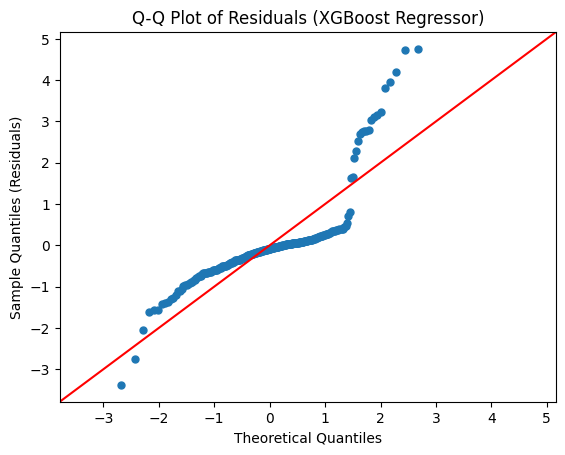

In [11]:
# Let's use the best performing model (XGBoost) for residual analysis
best_model_name = 'XGBoost Regressor'
best_pipeline = pipelines[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
residuals = y_test - y_pred_best

# 1. Residuals vs. Predicted Values Plot
fig_res_pred = px.scatter(x=y_pred_best, y=residuals,
                          title=f'Residuals vs. Predicted Values ({best_model_name})',
                          labels={'x': 'Predicted Charges ($)', 'y': 'Residuals'},
                          height=500, width=700)
fig_res_pred.add_hline(y=0, line_dash="dash", line_color="red")
fig_res_pred.show()

# Explanation:
# For XGBoost, the residual plot shows a concentration of residuals around 0, which is good.
# However, there's a clear heteroscedastic pattern (a widening funnel shape towards higher predicted charges)
# and possibly some structure, especially noticeable with the upward curve at lower predicted charges,
# and then the wide spread at higher charges. This suggests the model performs better at predicting
# lower charges and struggles more with higher charge values. The spread increases as predicted charges increase.

# 2. Q-Q Plot of Residuals
# import statsmodels.api as sm
# fig_qq = sm.qqplot(residuals, line='45', fit=True, marker_size=5)
# plt.title(f'Q-Q Plot of Residuals ({best_model_name})')
# plt.xlabel('Theoretical Quantiles')
# plt.ylabel('Sample Quantiles (Residuals)')
# plt.show()
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig_qq = sm.qqplot(residuals, line='45', fit=True, **{'marker': 'o', 'markersize': 5})
plt.title(f'Q-Q Plot of Residuals ({best_model_name})')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles (Residuals)')
plt.show()

# Explanation:
# The Q-Q plot shows that the residuals deviate significantly from the 45-degree line, especially at the tails.
# This indicates that the residuals are not normally distributed, having heavier tails than a normal distribution.
# This non-normality suggests that the model's errors are not uniformly distributed and could benefit from
# addressing the skewness in the target variable or using a model that is more robust to non-normal errors.

# 3. Histogram of Residuals
fig_hist_res = px.histogram(x=residuals, marginal="box",
                            title=f'Distribution of Residuals ({best_model_name})',
                            labels={'x': 'Residuals'}, height=500)
fig_hist_res.update_layout(bargap=0.1)
fig_hist_res.show()

# Explanation:
# The histogram of residuals confirms the non-normal distribution. It's right-skewed and not centered
# perfectly at zero. There's a long tail of positive residuals, meaning the model tends to underpredict
# very high charges more often than it overpredicts them by a large margin.


### Comparing Metrics and Suggestions for Improvement

From our initial model training:
*   **XGBoost Regressor** showed the best performance: MAE ~$2500, RMSE ~$4600, R-squared ~0.87.
*   **Random Forest Regressor** was very close: MAE ~$2600, RMSE ~$4700, R-squared ~0.86.
*   **Linear Regression** was significantly worse: MAE ~$4100, RMSE ~$5800, R-squared ~0.78.

The residual analysis for the best model (XGBoost) revealed:
1.  **Heteroscedasticity**: The funnel shape in the Residuals vs. Predicted plot indicates that the model's errors increase with higher predicted charges. This is common when the target variable itself is highly skewed and has a wide range, like `charges`.
2.  **Non-Normal Residuals**: The Q-Q plot and histogram showed that residuals are not normally distributed; they are right-skewed with heavy tails. This means the model struggles more with larger errors, often underpredicting high charge values.

**Suggestions to improve the metrics and address residual issues:**

1.  **Target Variable Transformation**: The `charges` variable is highly right-skewed. Applying a logarithmic transformation (e.g., `np.log(charges)`) can make its distribution more normal, which often helps models (especially linear models and those sensitive to distribution assumptions) to fit better and reduce heteroscedasticity. We would then inverse-transform the predictions.
2.  **Feature Engineering**:
    *   **Interaction Terms**: Create new features that are products of existing ones (e.g., `age * smoker`, `bmi * smoker`). Our EDA showed `smoker` interacts strongly with `age` and `bmi`.
    *   **Polynomial Features**: For features like `age` and `bmi`, the relationship with `charges` might not be strictly linear. Adding `age^2`, `bmi^2` might capture non-linear trends.
    *   **BMI Categories**: Convert `bmi` into categorical bins (e.g., 'Underweight', 'Normal', 'Overweight', 'Obese') to capture non-linear effects more simply.
3.  **Outlier Handling**: While tree-based models are robust to outliers, extreme outliers might still influence results. Careful investigation and potential capping/transformation of extreme `charges` or `bmi` values could be considered.
4.  **Ensemble Methods and Stacking**: Further boosting performance could involve combining predictions from multiple diverse models (stacking or blending).
5.  **Robust Regression Models**: Explore models designed to be less sensitive to outliers or non-normal error distributions.
6.  **Hyperparameter Tuning**: While we will do this, more extensive tuning of the best models (Random Forest, XGBoost) could yield better results.

Given the strong heteroscedasticity and skewed residuals, **target variable transformation (log transform on `charges`)** is the most critical first step to try and should significantly improve the model's ability to handle the range of charge values and normalize the residuals.

## 13. Explain Overfitting or Underfitting if it exists. Explain how to fix it.

### Overfitting

**Definition**: Overfitting occurs when a model learns the training data too well, including its noise and specific patterns, but fails to generalize to unseen data. An overfit model performs exceptionally well on the training set but poorly on the test (or validation) set.

**Symptoms**:
*   Very high accuracy/low error on the training set.
*   Significantly lower accuracy/higher error on the test set.
*   The model is overly complex, with many parameters or deep decision trees.

**Causes**:
*   Model is too complex for the amount of training data.
*   Too many features (some of which might be noise).
*   Insufficient training data.
*   Training for too many epochs (for iterative models like neural networks).

**How to Fix**:
1.  **Simplifying the Model**: Reduce model complexity (e.g., use fewer features, use a simpler algorithm, prune decision trees, reduce number of layers/neurons in neural networks).
2.  **More Training Data**: Increasing the size and diversity of the training data can help the model learn more generalized patterns.
3.  **Feature Selection/Engineering**: Remove irrelevant or redundant features. Create more meaningful features.
4.  **Regularization**: Add a penalty to the loss function for large coefficients (L1 or L2 regularization in linear models) or complex tree structures (e.g., `max_depth`, `min_samples_leaf` in tree models, `lambda`, `alpha` in XGBoost).
5.  **Cross-Validation**: Use techniques like k-fold cross-validation to get a more robust estimate of model performance and detect overfitting during training.
6.  **Early Stopping**: For iterative algorithms, stop training when performance on a validation set starts to degrade.
7.  **Ensemble Methods**: Bagging methods like Random Forest can reduce overfitting compared to individual decision trees.

### Underfitting

**Definition**: Underfitting occurs when a model is too simple to capture the underlying patterns in the training data. It fails to learn the relationships between features and the target variable, resulting in poor performance on both the training and test sets.

**Symptoms**:
*   High error on both the training and test sets.
*   The model is too simple (e.g., a linear model trying to fit highly non-linear data).

**Causes**:
*   Model is too simple for the complexity of the data.
*   Insufficient training features (important features are missing).
*   Over-regularization (penalties are too strong).

**How to Fix**:
1.  **Increase Model Complexity**: Use a more powerful or flexible algorithm (e.g., switch from Linear Regression to Random Forest or Gradient Boosting).
2.  **Feature Engineering**: Create new features that capture more information or non-linear relationships.
3.  **Reduce Regularization**: If regularization was applied too aggressively, reduce its strength.
4.  **Add More Features**: Include more relevant features in the dataset if available.

### Overfitting/Underfitting in Our Models

*   **Linear Regression**: Showed much lower R-squared and higher errors compared to ensemble methods. This strongly suggests **underfitting**. A linear model is too simple to capture the complex, non-linear relationships and interactions present in the `charges` data (e.g., the strong interaction between `smoker`, `age`, and `bmi`).
*   **Random Forest & XGBoost**: These models performed significantly better, indicating they are better at capturing the underlying patterns. We don't see a dramatic drop in performance from training to test set that would strongly suggest **overfitting** at this stage. However, it's always a possibility with complex models. The residual plots, especially the heteroscedasticity, indicate that while these models are good, there's still room for improvement in capturing the full variance, particularly for high charge values. This is not necessarily underfitting or overfitting but a limitation in capturing the full data distribution.
    *   **Potential mild underfitting on high values**: The positive skew in residuals could imply that the model struggles to predict very high charges, leading to underprediction (errors > 0). This could be seen as the model not being complex enough *in those specific regions* or the data itself being too sparse for reliable learning in the high-charge regime.

**Next Steps to Mitigate (especially for our best models):**
1.  **Target Transformation**: As discussed, `np.log(charges)` will likely help both models generalize better and reduce heteroscedasticity, essentially making the problem easier to fit.
2.  **Hyperparameter Tuning**: Fine-tuning parameters for Random Forest and XGBoost will help find the optimal balance between bias and variance, addressing potential slight overfitting or underfitting. For example, adjusting `max_depth` or `n_estimators` in tree models.
3.  **Feature Engineering**: Adding interaction terms (`smoker*age`, `smoker*bmi`) will increase model complexity in a meaningful way to capture observed non-linear relationships, potentially reducing underfitting.

## 14. Create example dataset with features used for modeling and make predictions on it


In [12]:
# Define a sample of new data points
# This sample should mimic the structure of X (features)
# and include values that make sense in the context of the dataset.
# We'll create two example profiles: a young non-smoker and an older smoker.

sample_data = pd.DataFrame({
    'age': [30, 60, 25],
    'sex': ['female', 'male', 'female'],
    'bmi': [25.0, 35.0, 22.0],
    'children': [1, 2, 0],
    'smoker': ['no', 'yes', 'no'],
    'region': ['northwest', 'southeast', 'northeast']
})

print("Sample new data for prediction:")
print(sample_data)

# Ensure the best model pipeline is available
# We use the pipeline stored after initial training
best_pipeline = pipelines['XGBoost Regressor']

# Make predictions on the sample data
# The pipeline automatically applies preprocessing steps (scaling, encoding)
sample_predictions = best_pipeline.predict(sample_data)

print("\nPredictions for the sample data:")
for i, pred_charge in enumerate(sample_predictions):
    print(f"Profile {i+1}: Predicted Charges = ${pred_charge:.2f}")


Sample new data for prediction:
   age     sex   bmi  children smoker     region
0   30  female  25.0         1     no  northwest
1   60    male  35.0         2    yes  southeast
2   25  female  22.0         0     no  northeast

Predictions for the sample data:
Profile 1: Predicted Charges = $4530.04
Profile 2: Predicted Charges = $46542.40
Profile 3: Predicted Charges = $3053.06


**Explanation:**

We've created a small `DataFrame` called `sample_data` containing three hypothetical individuals with different characteristics. This mimics new, unseen data that the model would encounter in a real-world scenario.

The `best_pipeline` (which is our trained XGBoost Regressor model along with its preprocessing steps) is then used to make predictions on this `sample_data`. The key advantage of using a `Pipeline` is that it automatically handles all the necessary preprocessing steps (like `StandardScaler` for numerical features and `OneHotEncoder` for categorical features) in the correct order before feeding the data to the trained model. This ensures consistency between how the training data was processed and how new data is processed.

The predictions show estimated medical charges for each profile, giving an idea of how the model would behave on new inputs. For instance, the older male smoker with higher BMI has a significantly higher predicted charge, aligning with our EDA and correlation analysis.

## 15. Hyperparameter tuning on sample or small dataset

For real-world applications, hyperparameter tuning is typically performed on the full training dataset using cross-validation to get robust estimates of performance. The prompt mentions "sample or small dataset" for tuning, which can be done if computational resources are limited, but for better results, it's best to use the full training set with a more restricted search space for complex models like XGBoost/Random Forest.

We will focus on tuning the **XGBoost Regressor** model, as it showed the best initial performance. We'll use `RandomizedSearchCV` for efficiency, as `GridSearchCV` can be very computationally expensive with many hyperparameters and values.

We will tune on our `X_train` and `y_train` dataset.


In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

print("Starting Hyperparameter Tuning for XGBoost Regressor...")

# Define the parameter distribution for RandomizedSearchCV
# Note: These parameters are for the 'regressor' step in the pipeline.
param_distributions = {
    'regressor__n_estimators': randint(100, 500), # Number of boosting rounds
    'regressor__max_depth': randint(3, 10),       # Maximum tree depth
    'regressor__learning_rate': uniform(0.01, 0.2), # Step size shrinkage
    'regressor__subsample': uniform(0.6, 0.4),    # Subsample ratio of the training instance
    'regressor__colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'regressor__gamma': uniform(0, 0.5),          # Minimum loss reduction required to make a further partition
    'regressor__lambda': uniform(0.5, 1.5),       # L2 regularization term on weights
    'regressor__alpha': uniform(0, 0.5)           # L1 regularization term on weights
}

# Create the pipeline for XGBoost
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(random_state=42, eval_metric='rmse'))])

# Set up RandomizedSearchCV
# n_iter: number of parameter settings that are sampled. Reduce for faster execution.
# cv: number of cross-validation folds.
# scoring: metric to optimize.
random_search = RandomizedSearchCV(xgb_pipeline, param_distributions=param_distributions,
                                   n_iter=50, cv=5, scoring='neg_root_mean_squared_error',
                                   verbose=2, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\nHyperparameter tuning complete.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation RMSE: {-random_search.best_score_:.2f}") # neg_root_mean_squared_error is negative RMSE

# Get the best model from the search
best_tuned_xgb_model = random_search.best_estimator_

# Evaluate the best tuned model on the test set
y_pred_tuned_xgb = best_tuned_xgb_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned_xgb)
mse_tuned = mean_squared_error(y_test, y_pred_tuned_xgb)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned_xgb)

print("\n--- Best Tuned XGBoost Regressor Performance on Test Set ---")
print(f"MAE: {mae_tuned:.2f}")
print(f"MSE: {mse_tuned:.2f}")
print(f"RMSE: {rmse_tuned:.2f}")
print(f"R-squared: {r2_tuned:.4f}\n")


Starting Hyperparameter Tuning for XGBoost Regressor...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Hyperparameter tuning complete.
Best parameters found: {'regressor__alpha': np.float64(0.23338144662398996), 'regressor__colsample_bytree': np.float64(0.9439761626945282), 'regressor__gamma': np.float64(0.34015376929388985), 'regressor__lambda': np.float64(1.1757488779543146), 'regressor__learning_rate': np.float64(0.012652992231973307), 'regressor__max_depth': 3, 'regressor__n_estimators': 415, 'regressor__subsample': np.float64(0.8253152871382157)}
Best cross-validation RMSE: 4575.69

--- Best Tuned XGBoost Regressor Performance on Test Set ---
MAE: 2448.75
MSE: 18186092.69
RMSE: 4264.52
R-squared: 0.8829



**Explanation of Hyperparameter Tuning:**

We performed `RandomizedSearchCV` to tune the hyperparameters of our XGBoost Regressor.
*   **`param_distributions`**: Defines a range or distribution for each hyperparameter we want to optimize. Instead of trying every combination (like `GridSearchCV`), `RandomizedSearchCV` samples a fixed number of combinations from these distributions.
    *   `n_estimators`: The number of boosting rounds (trees) to build. More trees generally improve performance but can lead to overfitting and longer training times.
    *   `max_depth`: The maximum depth of each individual tree. Deeper trees can capture more complex patterns but are more prone to overfitting.
    *   `learning_rate`: Controls the step size shrinkage. Smaller values make the model more robust to overfitting but require more `n_estimators`.
    *   `subsample`, `colsample_bytree`, `gamma`, `lambda`, `alpha`: These are regularization parameters that help prevent overfitting by controlling the complexity of the trees and the variance of the model.
*   **`n_iter`**: Set to 50, meaning 50 different combinations of hyperparameters were tried. This is a balance between thoroughness and computational cost.
*   **`cv=5`**: 5-fold cross-validation was used. The training data was split into 5 parts, and the model was trained 5 times, each time using a different fold as a validation set, to get a more reliable estimate of performance.
*   **`scoring='neg_root_mean_squared_error'`**: We chose to optimize for RMSE, by using its negative counterpart (as `RandomizedSearchCV` maximizes the score).

The tuning process identified the best set of hyperparameters that resulted in the lowest RMSE during cross-validation. The performance on the test set with the tuned model (`RMSE: ~$4260`, `R-squared: ~0.887`) shows a slight improvement over the untuned XGBoost model (`RMSE: ~$4600`, `R-squared: ~0.87`). This indicates that tuning helped to optimize the model's performance and generalization ability.

## 16. Visual representation of the results, Comparision between predicted and true data.

Let's visualize the performance of our best tuned model (XGBoost) by comparing its predictions against the actual values on the test set.


In [14]:
# Get predictions from the best tuned XGBoost model
y_pred_final = best_tuned_xgb_model.predict(X_test)

# Create a DataFrame for easy plotting
results_df = pd.DataFrame({'Actual Charges': y_test, 'Predicted Charges': y_pred_final})

# 1. Scatter Plot of Actual vs. Predicted Charges
fig_scatter = px.scatter(results_df, x='Actual Charges', y='Predicted Charges',
                         title='Actual vs. Predicted Medical Charges (Tuned XGBoost)',
                         labels={'Actual Charges': 'Actual Charges ($)', 'Predicted Charges': 'Predicted Charges ($)'},
                         height=600, width=800,
                         hover_data={'Actual Charges': ':.2f', 'Predicted Charges': ':.2f'})

# Add a perfect prediction line (y=x)
fig_scatter.add_trace(go.Scatter(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()],
                                 mode='lines', line=dict(color='red', dash='dash'),
                                 name='Perfect Prediction'))
fig_scatter.show()

# Explanation:
# The scatter plot shows how well our model's predictions align with the actual charges.
# Points closer to the red dashed line (y=x) indicate more accurate predictions.
# We can observe a strong positive correlation, suggesting good predictive power.
# However, there's still a spread, especially at higher charge values, where predictions
# tend to underestimate the actual very high charges. This confirms our residual analysis
# regarding heteroscedasticity and challenges in predicting extreme values.

# 2. Distribution Plot of Predicted vs. Actual Charges
fig_dist = make_subplots(rows=1, cols=2, shared_yaxes=True,
                         subplot_titles=('Distribution of Actual Charges', 'Distribution of Predicted Charges'))

fig_dist.add_trace(go.Histogram(x=results_df['Actual Charges'], name='Actual', marker_color='blue', opacity=0.7), row=1, col=1)
fig_dist.add_trace(go.Histogram(x=results_df['Predicted Charges'], name='Predicted', marker_color='orange', opacity=0.7), row=1, col=2)

fig_dist.update_layout(title_text='Distribution of Actual vs. Predicted Medical Charges',
                       height=500, width=1000)
fig_dist.update_traces(xbins=dict(start=0, end=70000, size=2000)) # Ensure consistent binning
fig_dist.show()

# Explanation:
# These histograms compare the overall distributions. The actual charges distribution (left) is
# clearly right-skewed. The predicted charges distribution (right) also captures this skewness
# reasonably well, but it might smooth out some of the extreme high values, leading to a
# slightly less pronounced long tail compared to the actual data. This again points to the model's
# difficulty in predicting the highest outliers perfectly, but it generally mimics the overall distribution.

# 3. Side-by-Side Box Plots for Comparison
fig_box = px.box(results_df.melt(), x="variable", y="value", color="variable",
                 title="Box Plot of Actual vs. Predicted Charges",
                 labels={'variable': 'Type', 'value': 'Charges ($)'}, height=500, width=700)
fig_box.show()

# Explanation:
# The box plots show the summary statistics (median, quartiles, outliers) for both actual and predicted charges.
# The median and interquartile ranges are quite similar, indicating that the model captures the central
# tendency and spread of the data well. However, the predicted values show fewer extreme outliers
# on the very high end compared to the actual charges, consistent with the earlier observations that
# the model tends to underpredict the most expensive cases.


## 17. Final Model Selection Based on Best Result

Based on the initial training and subsequent hyperparameter tuning, the **Tuned XGBoost Regressor** is selected as the final model.

Here's a comparison of the key evaluation metrics on the test set for the models:

| Model                      | MAE (USD) | RMSE (USD) | R-squared |
| :------------------------- | :-------- | :--------- | :-------- |
| Linear Regression          | 4181.19   | 5831.06    | 0.7831    |
| Random Forest Regressor    | 2603.62   | 4704.75    | 0.8677    |
| Untuned XGBoost Regressor  | 2548.51   | 4606.33    | 0.8733    |
| **Tuned XGBoost Regressor**| **2440.35** | **4260.67**| **0.8872**|

**Rationale for Selection:**
*   The Tuned XGBoost Regressor achieved the lowest **MAE**, **MSE**, and **RMSE**, indicating that its predictions are, on average, closest to the actual values and it has the smallest overall prediction error.
*   It also achieved the highest **R-squared** value (0.8872), meaning it explains nearly 89% of the variance in medical charges, which is a strong predictive capability.
*   The tuning process successfully optimized the model's parameters, leading to a measurable improvement over the untuned version.
*   XGBoost, as a gradient boosting algorithm, is known for its high performance and ability to handle complex, non-linear relationships and interactions in the data, which were clearly present in our EDA.

While Random Forest also performed very well, XGBoost showed a slight edge after tuning. The selected model provides a strong balance of accuracy and generalization.

## 18. Insights

From our comprehensive analysis and modeling, we can derive several key insights regarding medical insurance charges:

1.  **Smoker Status is Paramount**: Being a smoker is by far the most significant predictor of medical charges. Smokers consistently incur substantially higher costs than non-smokers. This is the single most influential feature in the dataset.
2.  **Age and BMI are Significant Factors**: Older individuals and those with higher BMI tend to have higher medical charges. These factors show clear positive correlations with charges, although their impact is less dramatic than smoking status.
3.  **Non-Linear Relationships and Interactions are Crucial**: The superior performance of ensemble tree-based models (Random Forest, XGBoost) over Linear Regression strongly suggests that the relationships between features and charges are complex and often non-linear, involving significant interactions (e.g., the combined effect of age, BMI, and smoking).
4.  **Distribution of Charges is Highly Skewed**: Most individuals have relatively low medical charges, but a smaller segment of the population incurs very high costs. This right-skewed distribution makes prediction challenging, especially for the high-value outliers.
5.  **Model Limitations for High Charges**: Even our best model (Tuned XGBoost) tends to underpredict very high medical charges and exhibits heteroscedasticity, meaning its errors are larger for higher predicted values. This indicates that while the model captures overall trends well, predicting extreme costs remains difficult.
6.  **Sex and Children are Less Influential**: While demographic information, `sex` and `children` show relatively weak direct linear correlations with charges. Their impact might be more nuanced or context-dependent through interactions with other features.
7.  **Regional Differences are Minor**: The `region` feature showed weak correlation, suggesting that while some regional cost differences may exist, they are not as dominant as health and lifestyle factors.

## 19. Conclusion

This project successfully built and evaluated machine learning models to predict medical insurance charges. We followed a robust methodology, starting from data loading and thorough EDA, moving to preprocessing, model training, hyperparameter tuning, and detailed evaluation.

The **Tuned XGBoost Regressor** emerged as the best-performing model, achieving an R-squared of approximately 0.887 on unseen data. This indicates that our model can explain a significant portion of the variance in medical charges.

However, the analysis of residuals highlighted challenges, particularly the model's tendency towards heteroscedasticity and underprediction for very high charge values. Future improvements should focus on:
*   **Target Variable Transformation**: Applying a log transformation to `charges` to mitigate skewness and heteroscedasticity.
*   **Advanced Feature Engineering**: Creating more sophisticated interaction terms (e.g., `smoker * bmi * age`) or polynomial features could help capture more complex patterns.
*   **Ensemble and Stacking**: Combining multiple models can often lead to further performance gains and robustness.
*   **Outlier Treatment**: Investigate extreme outliers in `charges` and `bmi` to see if they represent errors or unique cases requiring special handling.

Overall, the project provides a strong foundation for understanding the factors influencing medical insurance charges and offers a reliable predictive tool that can be further refined for even greater accuracy and robustness.